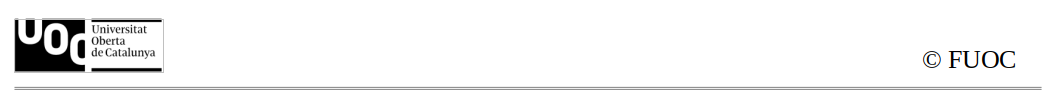
<div style="text-align: right;"> &#128337;Temps previst de dedicació: 30 minuts</div>

# Modularitat a Python

## Què és un mòdul?
Un mòdul a Python és un fitxer amb extensió .py, que alberga un conjunt de funcions, variables, classes (patrons d'objectes) i sentències executables.



## Mòduls i paquets

### Mòduls
Les definicions d'un mòdul poden ser importades a altres mòduls o al mòdul principal. Ens permeten reutilitzar codi i organitzar-lo millor.

Per exemple, podem definir un mòdul `modul_operacions_matematiques.py` amb dues funcions `suma()` i `resta()`.

```
# modul_operacions_matematiques.py
def suma(a, b):
    return a + b

def resta(a, b):
    return a - b
```
Una vegada definit, aquest mòdul pot ser usat o importat a un altre fitxer, com mostrem a continuació. Usant `import` podem importar tot el contingut.

```
# segonmodul.py
import modul_operacions_matematiques

print(modul_operacions_matematiques.suma(4, 3))   # 7
print(modul_operacions_matematiques.resta(10, 9)) # 1
```

També podem importar únicament els components que ens interessin com es mostra a continuació.

```
from modul_operacions_matematiques import suma, resta

print(suma(4, 3))   # 7
print(resta(10, 9)) # 1
```

Finalment, podem importar tot el mòdul fent ús de `*`, sense necessitat d'usar `modul_operacions_matematiques.*`.

```
from modul_operacions_matematiques import *

print(suma(4, 3))   # 7
print(resta(10, 9)) # 1
```
### Paquets

Un paquet és una carpeta que conté diversos mòduls. Seguint l'exemple anterior, podem dissenyar un paquet `primerpaquet` creant una carpeta amb la següent estructura.


```
#primerpaquet/
    |-- __init__.py
    |-- modul_operacions_matematiques.py
    |-- segonmodul.py
```
Ha de contenir sempre un arxiu `__init__.py` (de moment, buit) perquè Python entengui que es tracta d'un paquet i no d'una simple carpeta. Així, podem accedir a algun dels mòduls del paquet de la manera següent.
```
import primerpaquet.modul_operacions_matematiques
print(primerpaquet.modul_operacions_matematiques.sumar(7, 5))
```
O bé de la següent:

```
from primerpaquet import modul_operacions_matematiques
print(modul_operacions_matematiques.sumar(7, 5))
```
També, aquesta altra:

```
from primerpaquet.modul_operacions_matematiques import sumar
print(sumar(7, 5))
```




## Organització típica de codi a Python

Encara que és vàlid incloure tot el nostre codi en un sol fitxer .py, tard o d'hora qualsevol projecte ens obligarà a pensar en quina seria l'estructura ideal de paquets i mòduls.

A continuació, s'esmenten algunes regles que cal tenir en compte a l'hora d'usar paquets i mòduls.

*  Com es va esmentar anteriorment, Python reconeix un directori com un paquet si té dins un fitxer __init__.py. No cal que aquest fitxer tingui cap contingut, que estigui el fitxer és suficient.

*   Un paquet tindrà normalment mòduls però també pot contenir altres paquets (que bé podríem denominar subpaquets).

*    Normalment, el fitxer __init__.py estarà buit, però és cert que té un propòsit més gran i és permetre incloure codi d'inicialització del paquet.

Vegem primer un exemple amb fitxers __init__.py buits (i on main.py està fora del paquet per facilitar la resta dels exemples):


```
projecte\
    primerpaquet\
        _init_.py
        primermodul.py
        test_primermodul\
        subpaquete\
            _init_.py
            segonmodul.py
            test_segonmodul\
            utils\
            test\
    main.py
```
```
# menu.py
import primerpaquet.primermodul
import primerpaquet.subpaquet.segonmodul
```
La instrucció `import` admet múltiples variacions; el que es pretén explicar amb aquest exemple és que creem paquets i mòduls buscant organitzar el nostre codi sota la premissa de la modularitat.

Respecte a menu.py, cal esmentar que no té un significat especial per a Python. Podríem haver-lo anomenat principal.py i tot seguiria igual. La confusió sol venir perquè si el fitxer s'anomenés __menu__.py (s'assembla molt però no és el mateix) sí que és una cosa que Python entén com un cas especial.

**Dins d'un paquet:**

Una fet important quan fem servir __init__.py és la variable __all__. Té un ús concret i és quan s'utilitza la següent instrucció "from primerpaquet import *". Una cosa que és una mala pràctica, __all__ ens permet definir què s'exportarà i què no (en comptes de tots els mòduls). Si no utilitzem __all__, s'exportarà tot l'espai de noms disponible a __init__.py (excepte el que comenci per guió baix, que per convenció es considera privat).

```
# primerpaquet\__init__.py
import primerpaquet.primermodul as el_meu_primer_modul
import primerpaquet.subpaquet.segonmodul as el_meu_segon_modul

__all__ = ['el_meu_primer_modul']  #Només s'exporta el_meu_primer_modul
```
```
# menu.py
from primerpaquet import *

el_meu_primer_modul.primera_funcio()
el_meu_segon_modul.segona_funcio()  # Fallarà perquè no està a __all__
# primera_funcio() in primerpaquet/primermodul
# Traceback (most recent call last):
#   File "C:\Users\PycharmProyectos\PythonProyecto1\menu.py", line 4, in <modul>
#     el meu_segon_modul.segona_funcio()
# NameError: name 'el_meu_segon_modul' is not defined
```